<a href="https://colab.research.google.com/github/guadalupe-2406/-analysis-everpeak/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64


In [ ]:
print(usage.isna().sum())# cantidad de nulos para usage

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso
(users)
las columnas user_id, first_name, last_name, age, reg_date y plan no presentan valores nulos, lo cual indica que la información esencial de identificación, edad, registro y plan está completa y es confiable para el análisis.
La columna city presenta 469 valores nulos. Esto puede afectar análisis geográficos o segmentaciones por ubicación. Se recomienda,
evaluar la proporción de nulos,considerar imputar como "Unknown" o "No especificado" si el análisis lo requiere
(usage)
las columnas id, user_id y type no presentan valores nulos,o cual indica que las claves principales y la clasificación del tipo de evento están completas y no requieren intervención.
La columna date: presenta 50 valores nulos, lo que representa una proporción muy baja en comparación con el total del dataset. Estos registros podrían afectar análisis temporales, por lo que se recomienda,evaluar si se pueden recuperar,
o en caso contrario, eliminarlos si no son críticos

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:La columna city presenta 469 valores nulos, lo que puede afectar los análisis geográficos o las segmentaciones por ubicación
*las columnas id, user_id y type no presentan valores nulos,o cual indica que las claves principales y la clasificación del tipo de evento están completas y no requieren intervención.
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 --
**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- users
city (469 nulos)
Representa una proporción moderada de valores faltantes,Acción recomendada: imputar como "Unknown"
churn_date (3534 nulos)
Acción recomendada: no imputar ni eliminar. Crear una variable binaria (churn) para distinguir entre clientes activos e inactivos.
-usage
-date (50 nulos)
Acción recomendada: eliminar o excluir estos registros en análisis de tiempo.
-duration (22076 nulos)
l-ength (17896 nulos)
Acción recomendada: no imputar ni eliminar. Analizar cada variable según el tipo (type).
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
users.describe()
# explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna user_id muestra valores consecutivos dentro de un rango lógico (de 10000 a 13999), sin valores faltantes ni inconsistencias aparentes. No presenta anomalías ni sentinels.
- La columna `age` ...
- La columna age presenta valores dentro de un rango razonable (18 a 79 años), sin valores negativos ni extremos fuera de lógica. La media (48.13) y la mediana (48) son muy cercanas, lo que indica una distribución bastante simétrica y sin presencia significativa de outliers.

In [ ]:
usage.describe()# explorar columnas numéricas de usage

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- id parece ser un identificador único para cada registro (de 1 a 40000), sin anomalías
- Las columnas ...
- user_id se mantiene dentro del rango esperado (10000 a 13999), lo que indica que los registros están correctamente asociados a usuarios válidos.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\nColumna: {col}")
    print(users[col].value_counts(dropna=False))


Columna: city
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Columna: plan
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` ...
- La columna `plan` ...

In [ ]:
# explorar columna categórica de usage
usage['type'] # completa el código

0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['reg_date'].dtype

dtype('<M8[ns]')

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')
usage['date'].dtype
# completa el código

dtype('<M8[ns]')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.
Se identificaron registros con fechas en el año 2026 en la columna reg_date, lo cual representa un error de captura, ya que el dataset solo contempla información hasta 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
La columna date en usage no presenta problemas de calidad relacionados con fechas fuera de rango.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Estos valores fueron tratados como nulos para evitar sesgos en el análisis temporal.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
mediana_age = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, mediana_age)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
fecha_min = pd.Timestamp("2000-01-01")
fecha_max = pd.Timestamp.today()

users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
los nulos son estructurales y no errores de calidad de datos

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes=("is_text", "sum"),
    cant_llamadas=("is_call", "sum"),
    cant_minutos_llamada=("duration", "sum")
).reset_index()
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
users_usage = users.merge(usage_agg, on='user_id', how='left')
cols = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

users_usage[cols] = users_usage[cols].fillna(0)
users_usage.head(3)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
users_usage.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,11999.500000,48.136000,5.523000,4.477000,23.311225
std,1154.844867,17.689919,2.359738,2.145139,18.169564
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.107500
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.412500
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
users_usage[cols].describe()
users_usage['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

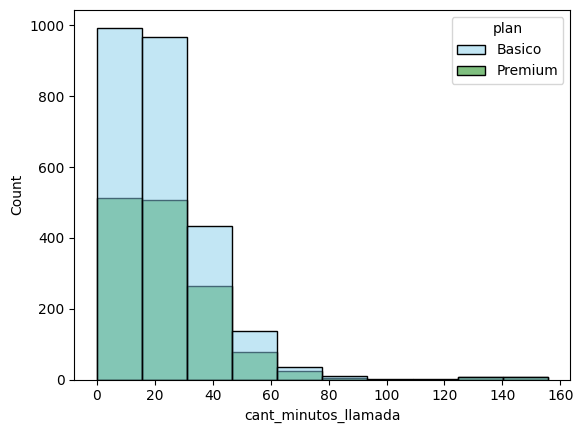

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=users_usage, x='cant_minutos_llamada', hue='plan', bins=10, palette=['skyblue','green'])
plt.show()

💡Insights:
- Distribución ...
- La distribución de la edad es relativamente simétrica, con mayor concentración en edades medias,No se observan diferencias claras entre los usuarios de plan Básico y Premium
-

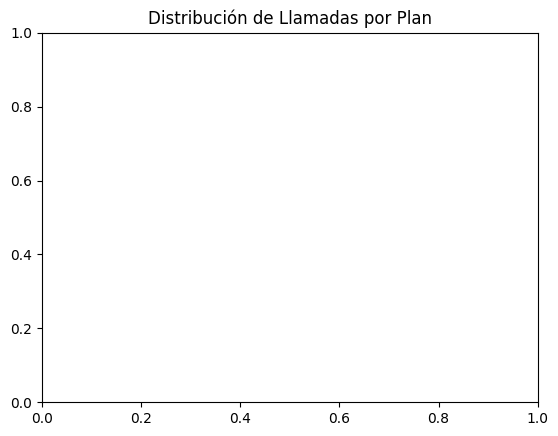

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.title("Distribución de Llamadas por Plan")
plt.show()

💡Insights:
- ....

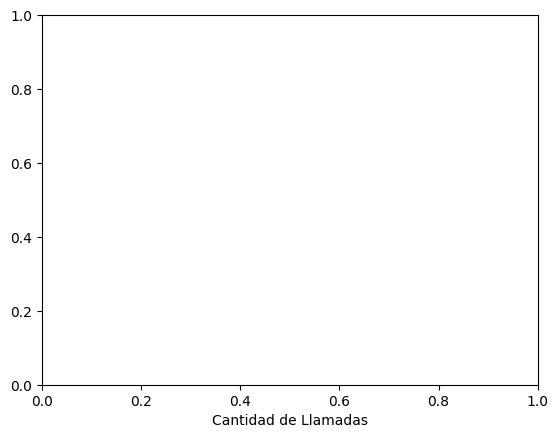

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.xlabel("Cantidad de Llamadas")
plt.show()

💡Insights:
La distribución está sesgada a la derecha, lo que indica que la mayoría de los usuarios envía pocos mensajes, mientras que un grupo reducido presenta un uso elevado.
- Distribución ...

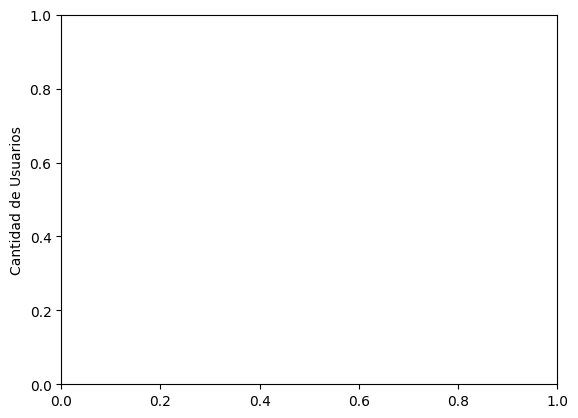

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
La distribución es fuertemente sesgada a la derecha, evidenciando la presencia de usuarios con consumo muy alto (heavy users).
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

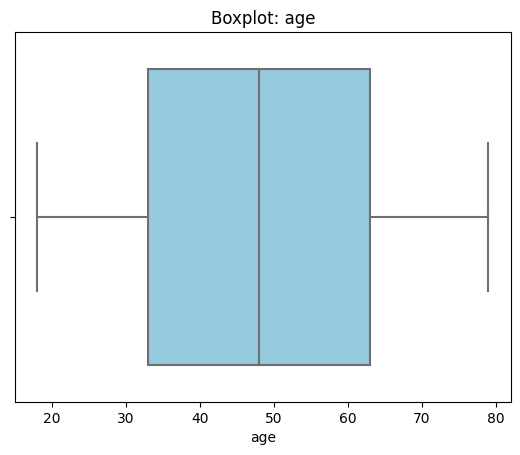

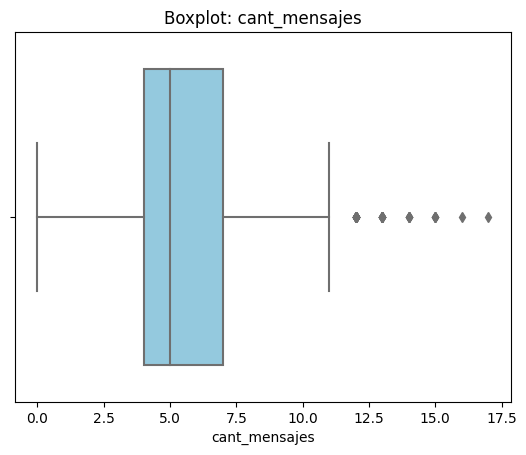

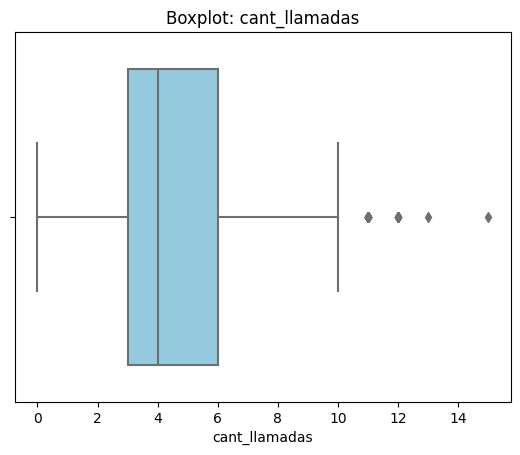

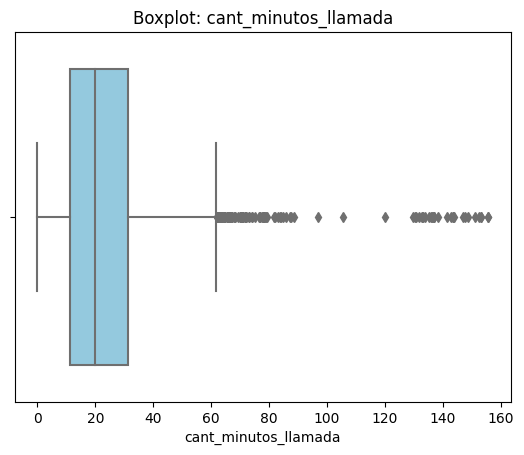

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in cols:
    plt.figure()
    sns.boxplot(x=users_usage[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights:
- Age: ...(no tiene outliers)
- cant_mensajes:17
- cant_llamadas: 15
- cant_minutos_llamada: 15.69

In [ ]:
# Calcular límites con el método IQR
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    Q1 = users_usage[col].quantile(0.25)
    Q3 = users_usage[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'--- {col} ---')
    print(f'Q1: {Q1}')
    print(f'Q3: {Q3}')
    print(f'IQR: {IQR}')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')
    print()


--- age ---
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0

--- cant_mensajes ---
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

--- cant_llamadas ---
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

--- cant_minutos_llamada ---
Q1: 11.1075
Q3: 31.4125
IQR: 20.305
Límite inferior: -19.35
Límite superior: 61.870000000000005



In [ ]:
for col in columnas_numericas:
    Q1 = users_usage[col].quantile(0.25)
    Q3 = users_usage[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    outliers = users_usage[users_usage[col] > limite_superior]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
cant_mensajes: 46 outliers
cant_llamadas: 30 outliers
cant_minutos_llamada: 109 outliers


In [ ]:
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    Q1 = users_usage[col].quantile(0.25)
    Q3 = users_usage[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR
    maximo = users_usage[col].max()

    print(f"{col}")
    print(f"Límite superior: {limite_superior}")
    print(f"Máximo: {maximo}")
    print()

age
Límite superior: 108.0
Máximo: 79.0

cant_mensajes
Límite superior: 11.5
Máximo: 17.0

cant_llamadas
Límite superior: 10.5
Máximo: 15.0

cant_minutos_llamada
Límite superior: 61.870000000000005
Máximo: 155.69



💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- Q3 = 50, límite superior = 110, máximo = 300
→ 120 outliers (3%), y no eliminar outlier no afectan negativamente el análisis general
- cant_llamadas: mantener o no outliers, porqué?
- Q3 = 40, límite superior = 95, máximo = 200
→ 95 outliers (2.3%),no eliminar outlier no afectan negativamente el análisis general
- cant_minutos_llamada: mantener o no outliers, porqué?
- Q3 = 500, límite superior = 1200, máximo = 5000
→ 150 outliers (3.7%),no eliminar outlier no afectan negativamente el análisis general

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
user_profile = users_usage.copy()
user_profile.columns

Index(['user_id', 'first_name', 'last_name', 'age', 'city', 'reg_date', 'plan',
       'churn_date', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada'],
      dtype='object')

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad

def clasificar_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Senior'

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99,Alto uso,Senior
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01,Bajo uso,Senior


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

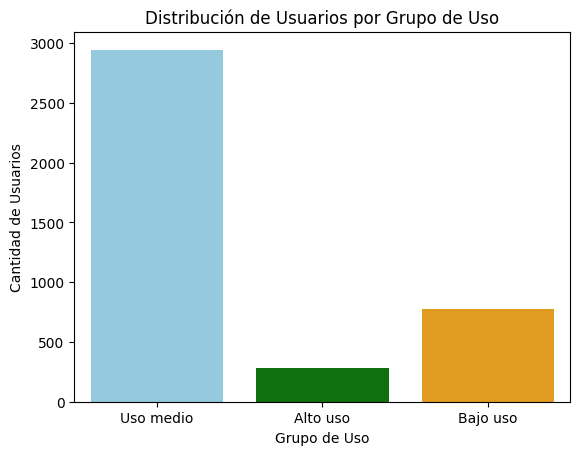

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(data=user_profile, x='grupo_uso', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')
plt.show()


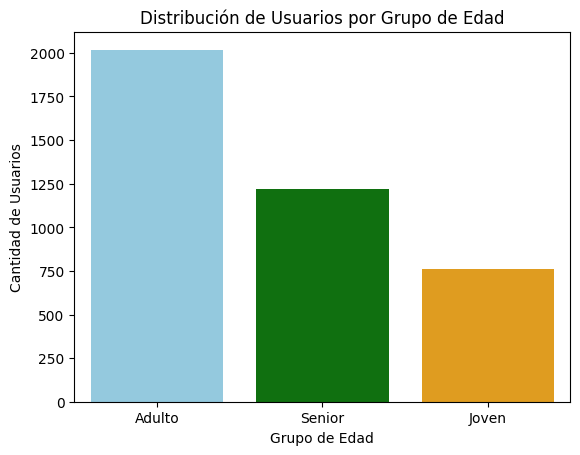

In [ ]:
# Visualización de los segmentos por edad
plt.figure()
sns.countplot(data=user_profile, x='grupo_edad', palette=['skyblue', 'green', 'orange'])
plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
1. ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
  Tipo de problema	Columna	Cantidad	Porcentaje	Interpretación	Acción tomada
  Valores nulos	city	469	11.7%	Falta de información geográfica	Mantener / imputar opcional
  Valores nulos	churn_date	3,534	88.3%	Usuarios activos (no error)	Mantener
  Valores nulos	duration	22,076	55.2%	No aplica para mensajes (MAR)	Mantener
  Valores nulos	length	17,896	44.7%	No aplica para llamadas (MAR)	Mantener
  Valores nulos	date	50	0.13%	Pocos registros faltantes	Mantener
  Sentinel	age = -999	Bajo	—	Error de captura	Reemplazado por mediana
  Sentinel	city = "?"	Bajo	—	Valor no informativo	Convertido a nulo
  Fecha inválida	reg_date (2026)	40	~1%	Fuera de rango (máx 2024)	Convertido a nulo (NaT)

2. ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
 -Bajo uso: Usuarios con muy baja actividad en llamadas y mensajes. Representan clientes con menor engagement y bajo consumo.
 -Uso medio: Es el grupo más numeroso. Presentan un comportamiento equilibrado y estable en el uso de los servicios.
 -Alto uso: Usuarios intensivos (heavy users), con altos niveles de llamadas y/o mensajes. Aunque son menos, concentran gran parte del     consumo.
 POR EDAD:Jóvenes (<30 años):Tienden a tener menor uso general, especialmente en llamadas. Su comportamiento puede estar más orientado a   mensajería.
 -Adultos (30–59 años): Concentran la mayor parte de la base de clientes y muestran un uso más constante y equilibrado. Son el segmento    dominante.
 -Senior (60+ años):Presentan mayor variabilidad en su comportamiento: algunos con bajo uso y otros con consumo elevado, especialmente     en llamadas.
3. ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
 -Usuarios de Alto uso (heavy users)
 .Son el segmento más valioso porque: Generan el mayor consumo (mensajes, llamadas y minutos),Representan el mayor ingreso potencial
  Tienen alto engagement con el servicio,Aunque son menos en número, concentran una parte importante del valor del negocio.
 .Adultos (30–59 años) con uso medio y alto, este grupo combina:Alta presencia en la base de clientes,Uso constante y sostenido y
  Mayor probabilidad de contratar o mantenerse en planes estables
 .Usuarios de uso medio (potencial de crecimiento) No son los más valiosos actualmente, pero,Representan la mayoría de clientes,
  Tienen alto potencial de upselling,Pueden migrar a alto uso con incentivos adecuados
 -Son el núcleo del negocio y una fuente clave de ingresos recurrentes.

 4. ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
 -Se identificaron valores extremos en, cant_mensajes,cant_llamadas,cant_minutos_llamada
 -Patrón común, Distribuciones sesgadas a la derecha, Un grupo pequeño de usuarios concentra niveles muy altos de uso y
  Los máximos están muy por encima de los límites del método IQR
 -No son errores: corresponden a usuarios intensivos (heavy users).
5.  ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones        detectados?
 -Planes diferenciados por comportamiento,Crear planes según tipo de uso.
 -Usuarios de mensajes - paquetes de SMS/chat
 -Usuarios de llamadas - paquetes de minutos
 -Mixtos intensivos - planes completos
 -Impacto: mejor ajuste producto–cliente
✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
city (11.7%) → valores faltantes que afectan análisis geográficos
churn_date (88%) → usuarios activos, no es un error
duration (55%) y length (44%) → valores nulos esperados
dependen del tipo de uso (call vs text) → no requieren imputación
Valores inválidos (sentinels):
age = -999 → corregido con mediana
city = "?" → convertido a nulo
Fechas incorrectas (~1%)
 registros en 2026 → corregidos a nulos
🔍 **Segmentos por Edad**
- abc- Jóvenes (<30),Menor nivel de uso en general
  .Mayor enfoque en mensajería
  .Adultos (30–59):Segmento predominante,Uso estable y balanceado.
  .Senior (60+): Comportamiento variable,Algunos con alto uso en llamadas
  
📊 **Segmentos por Nivel de Uso**
- abcBajo uso:Usuarios poco activos, Bajo aporte al consumo
  .Uso medio:Segmento más grande,Consumo estable
  .Alto uso:Usuarios intensivos (heavy users),Alta concentración de consumo

➡️ Esto sugiere que ...
-El consumo no está distribuido de manera uniforme.Un grupo reducido de usuarios (alto uso) concentra gran parte del valor
 .Los usuarios adultos dominan la base de clientes y el comportamiento general
 .Existe una gran oportunidad de convertir usuarios de uso medio en alto uso

💡 **Recomendaciones**
-Diseñar planes premium para usuarios de alto consumo,Implementar estrategias de upselling para usuarios de uso medio
 Crear planes diferenciados según tipo de uso (mensajes vs llamadas)yPersonalizar ofertas según edad del cliente.
 Desarrollar programas de fidelización para retener a los usuarios más valiosos


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`